<a href="https://colab.research.google.com/github/KAI-UTP/TFB3113-Data-Mining---January-2026/blob/main/Lab_4_Data_Warehouse_and_OLAP_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧪 Lab 4: Data Warehousing and OLAP (Enhanced + Diagrams)

This lab introduces the **design, implementation, and analytical use** of a **data warehouse** and **OLAP**. Operational systems (OLTP) are optimized to record day-to-day events (orders, payments, logins), but decision making requires **integrated, historical, and consistent data**. A data warehouse is built specifically to support **trend analysis, performance monitoring, dashboards, and data mining** through efficient aggregation and multidimensional viewing.

In this notebook, you will (1) simulate ETL, (2) build a dimensional model (star schema) in SQLite, (3) run OLAP-style queries (roll-up, drill-down, slice, dice, pivot), and (4) visualize key theory concepts with **schema diagrams** and a **cube lattice (cuboid hierarchy)** diagram. Each major section includes a second paragraph that explains what the accompanying source code is doing.

---

## 📦 Setup (Libraries)

A practical warehouse lab needs two categories of tools: (i) **data tooling** to generate/transform data and (ii) **query tooling** to store and analyze it. We will use `pandas`/`numpy` for data handling, `sqlite3` for a lightweight relational warehouse, and `matplotlib` (plus `networkx`) for diagram generation and visualization.

**Source code explanation:** The next cell imports the required libraries. `sqlite3` provides an in-memory database to mimic a warehouse without installing MySQL/PostgreSQL. `networkx` is used to draw schema and cube-lattice graphs as node-edge diagrams, while `matplotlib` renders them inside Colab.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Diagrams
import networkx as nx

---

# PART A — Core Concepts (with deeper theory)

## A1) What is a Data Warehouse?

A data warehouse is an **analytical data store** built to support decision making. The canonical definition highlights four properties: **subject-oriented** (organized by business themes like sales/customers), **integrated** (multiple sources reconciled into consistent naming, units, and keys), **time-variant** (stores snapshots across time for trend and seasonality), and **nonvolatile** (data is stable, typically appended via loads rather than overwritten). These properties are not “buzzwords”—they are design constraints that enable reproducible analytics (same query → same answer), historical comparison, and governance.

**Theoretical depth:** In practice, a warehouse also separates concerns: operational workloads (writes) are isolated from analytical workloads (reads). This reduces contention and allows optimizations for analytics such as denormalized dimensions, materialized aggregates, columnar storage (in many DW engines), and metadata-driven lineage. Many modern stacks implement ELT (load raw then transform) or ETL (transform then load), but the goals remain: trustworthy, query-efficient, business-aligned data.

**Source code explanation:** The next cell is an *answer cell*—students write their conceptual response into `answer_A1`. The code simply prints the answer so you can verify you wrote something before exporting.

In [4]:
# ✅ Exercise A1 (Answer Cell)
answer_A1 = (
    "A data warehouse is a centralized analytical repository that integrates cleaned data from multiple sources "
    "to support reporting and decision-making. It is subject-oriented, integrated, time-variant (stores historical "
    "data), and nonvolatile (stable/read-optimized rather than frequently updated like OLTP)."
)
print(answer_A1)

A data warehouse is a centralized analytical repository that integrates cleaned data from multiple sources to support reporting and decision-making. It is subject-oriented, integrated, time-variant (stores historical data), and nonvolatile (stable/read-optimized rather than frequently updated like OLTP).


## A2) OLTP vs OLAP (Why they differ)

**OLTP** systems capture transactions: many short queries, high concurrency, strict correctness, and frequent updates (INSERT/UPDATE/DELETE). **OLAP** systems serve analytics: fewer users but heavier queries, scanning large history, and aggregations (GROUP BY) across dimensions. OLAP benefits from star schemas, pre-aggregations, and sometimes specialized engines (column stores, MPP). This distinction explains why “just query the OLTP database for reports” often fails at scale: it slows production and produces inconsistent results when data changes mid-analysis.

**Theoretical depth:** OLTP schemas are often normalized (3NF) to reduce redundancy and avoid anomalies, while OLAP schemas are often denormalized (dimensional modeling) to reduce join complexity and maximize query speed. OLAP queries are frequently “read-mostly” and can leverage partitioning by time, materialized views, and bitmap/join indexing. Understanding the difference is essential for selecting the right model and tuning strategy.

**Source code explanation:** The next cell collects your classifications in a dictionary `answers_A2`. Using a dict keeps answers structured and easy to grade programmatically (e.g., auto-check keys `a`..`d`).

In [3]:
# ✅ Exercise A2 (Answer Cell)
answers_A2 = {"a": "", "b": "", "c": "", "d": ""}
print(answers_A2)

'''
Answer: OLTP supports day-to-day operations with many short, concurrent read/write transactions on current detailed data, usually in normalized schemas, prioritizing fast,
correct ACID transactions. OLAP supports analysis/reporting with fewer but heavy aggregate queries over large, historical integrated data, often using dimensional (star/snowflake)
schemas optimized for fast analytical queries. They differ because analytical workloads can slow transactional systems, and analytics benefits from read-optimized, historical,
integrated data structures.
'''

{'a': '', 'b': '', 'c': '', 'd': ''}


---

# PART B — Architecture & ETL Simulation

## B1) Multi-tier Architecture and ETL

A classic warehouse architecture includes **data sources → staging/ETL → warehouse storage → OLAP/BI tools**. ETL (or ELT) performs **extraction**, **cleaning**, **transformation**, **loading**, and **refresh**. The key is not only moving data, but enforcing consistency: standard time formats, currency normalization, key reconciliation (e.g., customer IDs), and data quality rules. Metadata (lineage, definitions, refresh time) is crucial for trust—without it, analytics becomes un-auditable.

**Theoretical depth:** ETL is where many real failures happen: duplicates inflate KPIs, slowly changing dimensions (SCD) can break historical reporting, and late-arriving facts can invalidate summaries. A robust design defines grain (the level of detail in facts), conformed dimensions (shared across marts), and loading strategies (batch vs streaming). Even in a toy lab, we mirror these ideas by generating a transactional dataset, then transforming it into dimension and fact tables.

**Source code explanation:** The next cells generate an OLTP-like dataset and place it into a staging table (`stg_orders`). This simulates a real pipeline where raw operational extracts land in staging first before being conformed into warehouse structures.

In [6]:
# Generate a mini OLTP-like transactional dataset
np.random.seed(42)

n = 2000
start_date = pd.Timestamp("2024-01-01")

products = [
    {"product_id": 1, "product_name": "Laptop", "brand": "Aster", "category": "Electronics"},
    {"product_id": 2, "product_name": "Phone", "brand": "Aster", "category": "Electronics"},
    {"product_id": 3, "product_name": "TV", "brand": "Nova", "category": "Electronics"},
    {"product_id": 4, "product_name": "Rice Cooker", "brand": "HomePro", "category": "Home"},
    {"product_id": 5, "product_name": "Vacuum", "brand": "HomePro", "category": "Home"},
]

cities = [
    {"city": "Kuala Lumpur", "state": "Selangor", "country": "Malaysia"},
    {"city": "Ipoh", "state": "Perak", "country": "Malaysia"},
    {"city": "Johor Bahru", "state": "Johor", "country": "Malaysia"},
    {"city": "Penang", "state": "Pulau Pinang", "country": "Malaysia"},
]

customers = [
    {"customer_id": 101, "segment": "Consumer"},
    {"customer_id": 102, "segment": "Corporate"},
    {"customer_id": 103, "segment": "SME"},
    {"customer_id": 104, "segment": "Consumer"},
    {"customer_id": 105, "segment": "Corporate"},
]

base_price = {"Laptop": 3200, "Phone": 1800, "TV": 2400, "Rice Cooker": 250, "Vacuum": 450}

rows = []
for i in range(n):
    p = products[np.random.randint(len(products))]
    c = customers[np.random.randint(len(customers))]
    loc = cities[np.random.randint(len(cities))]
    d = (start_date + pd.Timedelta(days=int(np.random.randint(0, 365)))).date().isoformat()
    qty = int(np.random.choice([1, 1, 1, 2, 2, 3]))
    amount = qty * base_price[p["product_name"]] * (0.9 + 0.2*np.random.rand())
    rows.append({
        "order_line_id": i+1,
        "order_date": d,
        "product_id": p["product_id"],
        "product_name": p["product_name"],
        "brand": p["brand"],
        "category": p["category"],
        "customer_id": c["customer_id"],
        "segment": c["segment"],
        "city": loc["city"],
        "state": loc["state"],
        "country": loc["country"],
        "quantity": qty,
        "amount": round(float(amount), 2)
    })

oltp_df = pd.DataFrame(rows)
oltp_df.head()

,order_line_id,order_date,product_id,product_name,brand,category,customer_id,segment,city,state,country,quantity,amount
0,1,2024-04-16,4,Rice Cooker,HomePro,Home,105,Corporate,Johor Bahru,Johor,Malaysia,2,509.69
1,2,2024-11-26,2,Phone,Aster,Electronics,103,SME,Johor Bahru,Johor,Malaysia,1,1931.82
2,3,2024-11-04,4,Rice Cooker,HomePro,Home,103,SME,Ipoh,Perak,Malaysia,1,261.10
3,4,2024-06-09,2,Phone,Aster,Electronics,104,Consumer,Kuala Lumpur,Selangor,Malaysia,2,3680.39
4,5,2024-02-18,5,Vacuum,HomePro,Home,104,Consumer,Kuala Lumpur,Selangor,Malaysia,1,460.07


### ✅ Exercise B1 (ETL Thinking)

Even though this dataset is “clean” (because we generated it), real ETL must anticipate messy inputs: missing values, inconsistent units, mismatched codes, duplicated rows, and late corrections. Think about how you would standardize identifiers, validate constraints (e.g., non-negative quantity), and ensure a consistent time dimension.

**Source code explanation:** This cell is an answer placeholder. You will write an ETL plan into `answer_B1`. In a real pipeline, your plan would be implemented as transformations (SQL or Python) before loading the dimensional model.

In [11]:
answer_B1 = """
ETL Plan

1) Extract (Data Sources → Staging)
- Pull raw data from operational sources (CSV/DB/APIs).
- Keep an unchanged “raw” copy in staging for audit + reprocessing.

2) Validate & Clean (Staging)
- Check schema: required columns exist, correct data types.
- Handle missing values: impute (e.g., unknown category) or reject rows based on rules.
- Remove duplicates using a business key (e.g., transaction_id) + timestamp.
- Constraint checks: quantity ≥ 0, amount ≥ 0, valid dates, valid codes.

3) Transform (Staging → Warehouse-ready)
- Standardize formats/units: date-time timezone, currency, text casing, category codes.
- Conform identifiers: reconcile mismatched customer/product IDs (lookup tables / mapping).
- Create a consistent Time Dimension: year, quarter, month, week, day.
- Derive fields: total_amount = quantity * unit_price, profit, discount flags, etc.

4) Load (Warehouse Storage)
- Load/update Dimension tables first (Customer, Product, Time, Location) using surrogate keys.
- Load Fact table (Sales) with foreign keys to dimensions and measures (qty, amount).
- Use incremental loads (CDC / “newer_than last_run”) instead of full reload when possible.

5) Refresh & Monitoring (Warehouse → OLAP/BI)
- Schedule refresh (daily/hourly depending on need).
- Track metadata: lineage, definitions, load time, row counts, error logs.
- Data quality reporting: rejected rows, rule violations, late corrections handling.
"""
print(answer_B1)


ETL Plan (Multi-tier Architecture)

1) Extract (Data Sources → Staging)
- Pull raw data from operational sources (CSV/DB/APIs).
- Keep an unchanged “raw” copy in staging for audit + reprocessing.

2) Validate & Clean (Staging)
- Check schema: required columns exist, correct data types.
- Handle missing values: impute (e.g., unknown category) or reject rows based on rules.
- Remove duplicates using a business key (e.g., transaction_id) + timestamp.
- Constraint checks: quantity ≥ 0, price ≥ 0, valid dates, valid codes.

3) Transform (Staging → Warehouse-ready)
- Standardize formats/units: date-time timezone, currency, text casing, category codes.
- Conform identifiers: reconcile mismatched customer/product IDs (lookup tables / mapping).
- Create a consistent Time Dimension: year, quarter, month, week, day.
- Derive fields: total_amount = quantity * unit_price, profit, discount flags, etc.

4) Load (Warehouse Storage)
- Load/update Dimension tables first (Customer, Product, Time, Locati

---

# PART C — Dimensional Modeling (Star + Snowflake) + Diagrams

## C1) Dimensional Modeling: Facts, Dimensions, and Grain

Dimensional modeling organizes analytic data using a **fact table** (events + measures) and **dimension tables** (descriptive context). Choosing the right **grain** is fundamental: it defines what one fact row represents (e.g., “one order line per day per product per customer per location”). A consistent grain ensures that aggregations (SUM/COUNT/AVG) produce meaningful results and prevents double-counting.

**Theoretical depth:** Dimensions often have hierarchies (day→month→quarter→year; city→state→country). Star schemas keep dimensions denormalized for simplicity and speed; snowflake schemas normalize parts of a dimension to reduce redundancy but increase join complexity. Most BI tools and OLAP patterns assume star-like access; snowflaking is used selectively when dimensions become very large or governance requires strict normalization.

**Source code explanation:** The following code creates an in-memory SQLite warehouse, loads the OLTP dataset into a staging table, then builds dimension tables (`dim_time`, `dim_product`, `dim_customer`, `dim_location`) and a fact table (`fact_sales`). It uses SQL joins to map business identifiers (e.g., `product_id`) into surrogate keys (e.g., `product_key`) to support stable, compact joins.

In [12]:
# Helper functions for SQL execution
def run_sql(conn, query, params=None):
    params = params or ()
    return pd.read_sql_query(query, conn, params=params)

def exec_sql(conn, query, params=None):
    params = params or ()
    cur = conn.cursor()
    cur.execute(query, params)
    conn.commit()

# Create the warehouse (in-memory)
conn = sqlite3.connect(":memory:")

# Stage the OLTP data
oltp_df.to_sql("stg_orders", conn, index=False, if_exists="replace")
run_sql(conn, "SELECT COUNT(*) AS rows_in_staging FROM stg_orders;")

,rows_in_staging
0,2000


In [13]:
# dim_time
exec_sql(conn, '''
CREATE TABLE dim_time (
    time_key INTEGER PRIMARY KEY,
    date TEXT UNIQUE,
    year INTEGER,
    month INTEGER,
    quarter INTEGER,
    day_of_week INTEGER
);
''')

dates = pd.to_datetime(oltp_df["order_date"]).drop_duplicates().sort_values()
dim_time = pd.DataFrame({
    "date": dates.dt.date.astype(str),
    "year": dates.dt.year,
    "month": dates.dt.month,
    "quarter": ((dates.dt.month - 1) // 3 + 1),
    "day_of_week": dates.dt.dayofweek
})
dim_time["time_key"] = np.arange(1, len(dim_time)+1)
dim_time.to_sql("dim_time", conn, index=False, if_exists="append")

# dim_product
exec_sql(conn, '''
CREATE TABLE dim_product (
    product_key INTEGER PRIMARY KEY,
    product_id INTEGER UNIQUE,
    product_name TEXT,
    brand TEXT,
    category TEXT
);
''')
dim_product = oltp_df[["product_id","product_name","brand","category"]].drop_duplicates().sort_values("product_id")
dim_product["product_key"] = np.arange(1, len(dim_product)+1)
dim_product.to_sql("dim_product", conn, index=False, if_exists="append")

# dim_customer
exec_sql(conn, '''
CREATE TABLE dim_customer (
    customer_key INTEGER PRIMARY KEY,
    customer_id INTEGER UNIQUE,
    segment TEXT
);
''')
dim_customer = oltp_df[["customer_id","segment"]].drop_duplicates().sort_values("customer_id")
dim_customer["customer_key"] = np.arange(1, len(dim_customer)+1)
dim_customer.to_sql("dim_customer", conn, index=False, if_exists="append")

# dim_location
exec_sql(conn, '''
CREATE TABLE dim_location (
    location_key INTEGER PRIMARY KEY,
    city TEXT,
    state TEXT,
    country TEXT,
    UNIQUE(city, state, country)
);
''')
dim_location = oltp_df[["city","state","country"]].drop_duplicates().sort_values(["country","state","city"])
dim_location["location_key"] = np.arange(1, len(dim_location)+1)
dim_location.to_sql("dim_location", conn, index=False, if_exists="append")

run_sql(conn, "SELECT COUNT(*) AS products FROM dim_product;")

,products
0,5


In [14]:
# fact_sales
exec_sql(conn, '''
CREATE TABLE fact_sales (
    sales_key INTEGER PRIMARY KEY,
    time_key INTEGER,
    product_key INTEGER,
    customer_key INTEGER,
    location_key INTEGER,
    quantity INTEGER,
    amount REAL,
    FOREIGN KEY(time_key) REFERENCES dim_time(time_key),
    FOREIGN KEY(product_key) REFERENCES dim_product(product_key),
    FOREIGN KEY(customer_key) REFERENCES dim_customer(customer_key),
    FOREIGN KEY(location_key) REFERENCES dim_location(location_key)
);
''')

exec_sql(conn, '''
INSERT INTO fact_sales (time_key, product_key, customer_key, location_key, quantity, amount)
SELECT
    t.time_key,
    p.product_key,
    c.customer_key,
    l.location_key,
    s.quantity,
    s.amount
FROM stg_orders s
JOIN dim_time t      ON t.date = s.order_date
JOIN dim_product p   ON p.product_id = s.product_id
JOIN dim_customer c  ON c.customer_id = s.customer_id
JOIN dim_location l  ON l.city = s.city AND l.state = s.state AND l.country = s.country;
''')

run_sql(conn, "SELECT COUNT(*) AS fact_rows FROM fact_sales;")

,fact_rows
0,2000


### ✅ Exercise C1
Why do we use a fact table + dimensions? What do surrogate keys help with?

**Source code explanation:** Write your explanation in `answer_C1`. Surrogate keys in the code (e.g., `product_key`) decouple analytics from operational IDs, supporting consistent joins even if source systems change identifiers or data arrives from multiple systems.

In [16]:
# ✅ Exercise C1 (Answer Cell)
answer_C1 = """
We use a fact table + dimensions to separate “measurements” from “context”.
- Fact table stores numeric measures (e.g., amount, quantity) at a defined grain (e.g., one row per sale) and contains foreign keys to dimensions.
- Dimension tables store descriptive attributes (who/what/when/where) like customer, product, time, location, enabling fast GROUP BY, filtering (slice/dice), and drill-down/roll-up.

Surrogate keys help because they:
- Provide stable integer keys even if source system IDs change or are messy.
- Let's us integrate multiple sources that may have different natural keys.
- Support slowly changing dimensions (track history) by creating new dimension rows without breaking fact records.
- Improve performance (smaller integer joins) and reduce dependency on business and natural keys.
"""
print(answer_C1)


We use a fact table + dimensions to separate “measurements” from “context”.
- Fact table stores numeric measures (e.g., amount, quantity) at a defined grain (e.g., one row per sale) and contains foreign keys to dimensions.
- Dimension tables store descriptive attributes (who/what/when/where) like customer, product, time, location, enabling fast GROUP BY, filtering (slice/dice), and drill-down/roll-up.

Surrogate keys help because they:
- Provide stable integer keys even if source system IDs change or are messy.
- Let us integrate multiple sources that may have different natural keys.
- Support slowly changing dimensions (track history) by creating new dimension rows without breaking fact records.
- Improve performance (smaller integer joins) and reduce dependency on business/natural keys.



## C2) Diagram: Star Schema (Fact in center)

A star schema places the **fact table** at the center and connects it to denormalized dimensions. This structure is popular because it makes analytical queries intuitive (“sum sales by time, product, and location”) and efficient for OLAP tools.

**Source code explanation:** The next cell draws a star schema using `networkx`. Nodes represent tables and edges represent foreign-key relationships from `fact_sales` to each dimension. We use a fixed layout to keep the fact table in the center for readability.

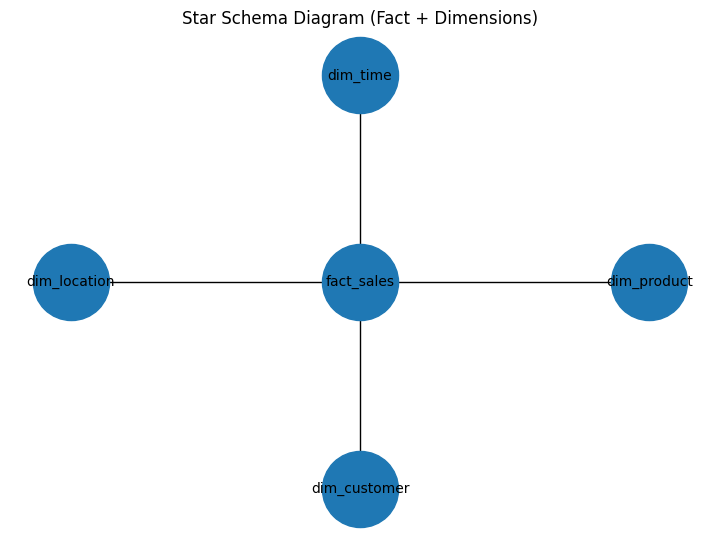

In [17]:
G = nx.Graph()
fact = "fact_sales"
dims = ["dim_time", "dim_product", "dim_customer", "dim_location"]

G.add_node(fact, kind="fact")
for d in dims:
    G.add_node(d, kind="dim")
    G.add_edge(fact, d)

pos = {
    fact: (0, 0),
    "dim_time": (0, 1.6),
    "dim_product": (1.8, 0),
    "dim_customer": (0, -1.6),
    "dim_location": (-1.8, 0),
}

plt.figure(figsize=(7,5))
nx.draw(G, pos, with_labels=True, node_size=3000, font_size=10)
plt.title("Star Schema Diagram (Fact + Dimensions)")
plt.axis("off")
plt.show()

## C3) Diagram: Snowflake Schema (Normalized dimension hierarchy)

A snowflake schema normalizes parts of a dimension into multiple related tables. For example, a **Location** dimension can be split into City → State → Country tables. This reduces redundancy (country name repeated many times) but introduces extra joins.

**Source code explanation:** The next cell draws a conceptual snowflake. We keep `fact_sales` connected to base dimensions, but we “snowflake” the location and product dimensions into sub-dimensions (e.g., `dim_city`→`dim_state`→`dim_country`, and `dim_product`→`dim_brand`→`dim_category`). This is a conceptual diagram to visualize normalized hierarchies.

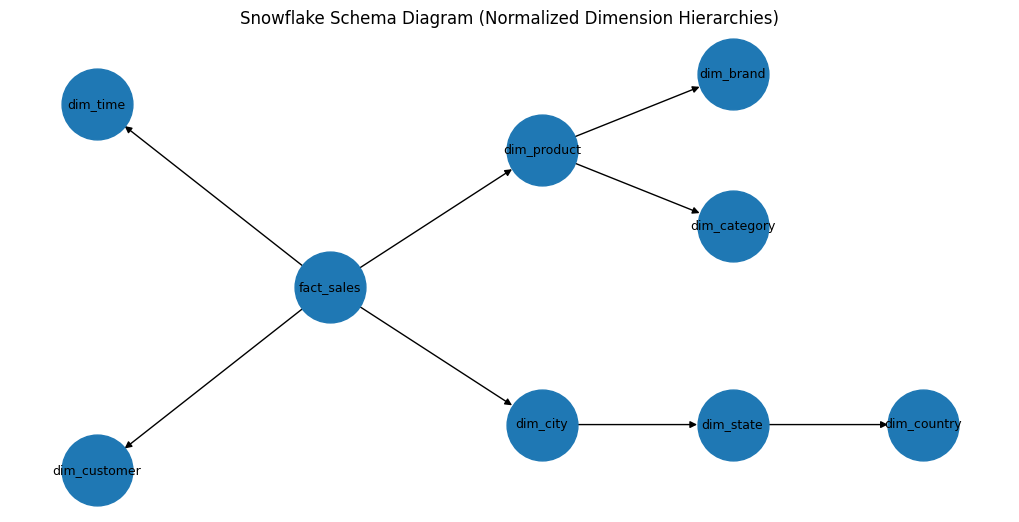

In [18]:
H = nx.DiGraph()

# Core
H.add_edges_from([
    ("fact_sales", "dim_time"),
    ("fact_sales", "dim_product"),
    ("fact_sales", "dim_customer"),
    ("fact_sales", "dim_city"),
])

# Snowflake: location hierarchy
H.add_edges_from([
    ("dim_city", "dim_state"),
    ("dim_state", "dim_country"),
])

# Snowflake: product hierarchy
H.add_edges_from([
    ("dim_product", "dim_brand"),
    ("dim_product", "dim_category"),
])

# Positioning
pos = {
    "fact_sales": (0, 0),
    "dim_time": (-2.2, 1.2),
    "dim_customer": (-2.2, -1.2),
    "dim_product": (2.0, 0.9),
    "dim_brand": (3.8, 1.4),
    "dim_category": (3.8, 0.4),
    "dim_city": (2.0, -0.9),
    "dim_state": (3.8, -0.9),
    "dim_country": (5.6, -0.9),
}

plt.figure(figsize=(10,4.8))
nx.draw(H, pos, with_labels=True, node_size=2600, font_size=9, arrows=True, arrowstyle="-|>")
plt.title("Snowflake Schema Diagram (Normalized Dimension Hierarchies)")
plt.axis("off")
plt.show()

---

# PART D — OLAP Operations (SQL) + Code Walkthrough

## D1) OLAP Operations: roll-up, drill-down, slice, dice, pivot

OLAP operations are best understood as **transformations of aggregation level and filtering across dimensions**. Roll-up aggregates up a hierarchy (daily→monthly→yearly). Drill-down moves to detail (yearly→monthly→daily). Slice fixes one dimension to a single value (e.g., category='Electronics'), while dice applies multiple filters to extract a sub-cube (e.g., category='Electronics' AND state='Perak' AND quarter=2). Pivot rotates axes to view the same cube from another perspective, typically presented as cross-tabs.

**Theoretical depth:** In data cube terms, a query selects a **cuboid** (a specific set of dimensions at specific hierarchy levels). Query performance depends on whether that cuboid (or a compatible higher-level aggregate) is materialized. Even without explicit cube materialization, SQL GROUP BY can compute cuboids on demand; however, large warehouses rely on partitioning, indexes, and pre-aggregations to keep query latency acceptable.

**Source code explanation:** The following code cells run SQL over the star schema. Each query joins the fact table to relevant dimensions, then uses `GROUP BY` to compute aggregations (our “cube” behavior). The same logic maps directly to real DW engines—only the scale and optimizations differ.

In [19]:
# Roll-up: monthly sales
run_sql(conn, '''
SELECT
    t.year,
    t.month,
    ROUND(SUM(f.amount), 2) AS total_sales
FROM fact_sales f
JOIN dim_time t ON f.time_key = t.time_key
GROUP BY t.year, t.month
ORDER BY t.year, t.month;
''').head(12)

,year,month,total_sales
0,2024,1,441487.83
1,2024,2,383241.17
2,2024,3,418684.85
3,2024,4,470348.88
4,2024,5,501096.27
5,2024,6,408909.75
6,2024,7,526859.66
7,2024,8,475077.13
8,2024,9,462349.98
9,2024,10,459720.52


In [20]:
# Drill-down: daily sales for a selected month
selected_year = 2024
selected_month = 6

run_sql(conn, '''
SELECT
    t.date,
    ROUND(SUM(f.amount), 2) AS daily_sales
FROM fact_sales f
JOIN dim_time t ON f.time_key = t.time_key
WHERE t.year = ? AND t.month = ?
GROUP BY t.date
ORDER BY t.date;
''', (selected_year, selected_month)).head(10)

,date,daily_sales
0,2024-06-01,15306.79
1,2024-06-02,12704.06
2,2024-06-03,22406.04
3,2024-06-04,16250.79
4,2024-06-05,33199.20
5,2024-06-06,23996.03
6,2024-06-07,14031.65
7,2024-06-08,7726.51
8,2024-06-09,28945.58
9,2024-06-10,18615.85


In [21]:
# Slice: filter one dimension value (category)
run_sql(conn, '''
SELECT
    t.year,
    t.month,
    p.category,
    ROUND(SUM(f.amount), 2) AS total_sales
FROM fact_sales f
JOIN dim_time t ON f.time_key = t.time_key
JOIN dim_product p ON f.product_key = p.product_key
WHERE p.category = 'Electronics'
GROUP BY t.year, t.month, p.category
ORDER BY t.year, t.month;
''').head(12)

,year,month,category,total_sales
0,2024,1,Electronics,396510.58
1,2024,2,Electronics,346397.97
2,2024,3,Electronics,380623.68
3,2024,4,Electronics,430273.68
4,2024,5,Electronics,456508.06
5,2024,6,Electronics,369957.40
6,2024,7,Electronics,490366.99
7,2024,8,Electronics,434317.10
8,2024,9,Electronics,429884.43
9,2024,10,Electronics,405814.12


In [22]:
# Dice: multiple filters (category + state + quarter)
run_sql(conn, '''
SELECT
    t.year,
    t.quarter,
    l.state,
    p.category,
    ROUND(SUM(f.amount), 2) AS total_sales
FROM fact_sales f
JOIN dim_time t ON f.time_key = t.time_key
JOIN dim_product p ON f.product_key = p.product_key
JOIN dim_location l ON f.location_key = l.location_key
WHERE p.category = 'Electronics'
  AND l.state = 'Perak'
  AND t.quarter = 2
GROUP BY t.year, t.quarter, l.state, p.category;
''')

,year,quarter,state,category,total_sales
0,2024,2,Perak,Electronics,314335.23


In [23]:
# Pivot (cross-tab): category x quarter
run_sql(conn, '''
SELECT
    p.category,
    ROUND(SUM(CASE WHEN t.quarter = 1 THEN f.amount ELSE 0 END), 2) AS Q1,
    ROUND(SUM(CASE WHEN t.quarter = 2 THEN f.amount ELSE 0 END), 2) AS Q2,
    ROUND(SUM(CASE WHEN t.quarter = 3 THEN f.amount ELSE 0 END), 2) AS Q3,
    ROUND(SUM(CASE WHEN t.quarter = 4 THEN f.amount ELSE 0 END), 2) AS Q4
FROM fact_sales f
JOIN dim_time t ON f.time_key = t.time_key
JOIN dim_product p ON f.product_key = p.product_key
GROUP BY p.category
ORDER BY p.category;
''')

,category,Q1,Q2,Q3,Q4
0,Electronics,1123532.23,1256739.14,1354568.52,1132359.13
1,Home,119881.62,123615.76,109718.25,132662.57


### ✅ Exercise D1 (Write SQL)

Write your own SQL strings below.

**Source code explanation:** These are blank strings for you to fill. Keeping them as Python variables makes it easy for instructors to auto-run and check results (optional), but you can also just submit the notebook with your SQL text.

In [24]:
# ✅ Exercise D1 (Answer Cell)

# ROLL-UP
sql_rollup_year = """
SELECT
  t.year,
  SUM(f.amount) AS total_sales,
  SUM(f.quantity) AS total_qty
FROM fact_sales f
JOIN dim_time t ON f.time_key = t.time_key
GROUP BY t.year
ORDER BY t.year;
"""

# SLICE
sql_slice_2024 = """
SELECT
  p.category,
  SUM(f.amount) AS total_sales,
  SUM(f.quantity) AS total_qty
FROM fact_sales f
JOIN dim_time t ON f.time_key = t.time_key
JOIN dim_product p ON f.product_key = p.product_key
WHERE t.year = 2024
GROUP BY p.category
ORDER BY total_sales DESC;
"""

# DICE
sql_dice = """
SELECT
  t.year, t.quarter,
  l.state,
  p.category,
  SUM(f.amount) AS total_sales
FROM fact_sales f
JOIN dim_time t ON f.time_key = t.time_key
JOIN dim_product p ON f.product_key = p.product_key
JOIN dim_location l ON f.location_key = l.location_key
WHERE p.category = 'Electronics'
  AND l.state = 'Perak'
  AND t.quarter = 2
GROUP BY t.year, t.quarter, l.state, p.category
ORDER BY t.year, t.quarter;
"""

# DRILL-DOWN
sql_drilldown_year_to_month = """
SELECT
  t.year,
  t.month,
  SUM(f.amount) AS total_sales,
  SUM(f.quantity) AS total_qty
FROM fact_sales f
JOIN dim_time t ON f.time_key = t.time_key
WHERE t.year = 2024
GROUP BY t.year, t.month
ORDER BY t.year, t.month;
"""

print(sql_rollup_year)


SELECT
  t.year,
  SUM(f.amount) AS total_sales,
  SUM(f.quantity) AS total_qty
FROM fact_sales f
JOIN dim_time t ON f.time_key = t.time_key
GROUP BY t.year
ORDER BY t.year;



---

# PART E — Data Cubes, Cuboids, and the Cube Lattice (Full hierarchy visualization)

## E1) Cuboids and the Cube Lattice

A **data cube** is the collection of all aggregations (cuboids) across dimensions. With *n* dimensions (ignoring hierarchy levels), there are **2^n** possible cuboids: from the **base cuboid** (all dimensions) up to the **apex cuboid** (ALL aggregated). The **lattice** organizes cuboids by dimensionality: 4D at the bottom, 3D above it, then 2D, 1D, and 0D at the top.

**Theoretical depth:** When dimensions have multiple hierarchy levels (e.g., day→month→year), the number of potential cuboids grows further because each dimension can be aggregated at different levels. Practical systems therefore select a subset to materialize (materialized views) based on workload. Query rewriting then chooses the “closest” materialized cuboid to answer a query with minimal cost.

**Source code explanation:** The next cell draws a **full cube lattice for 4 dimensions** (Time, Product, Location, Customer). Each node is a cuboid represented by the set of included dimensions. Edges connect cuboids that differ by exactly one dimension (roll-up/drill-down relationship). This is a faithful visualization of the cuboid hierarchy concept.

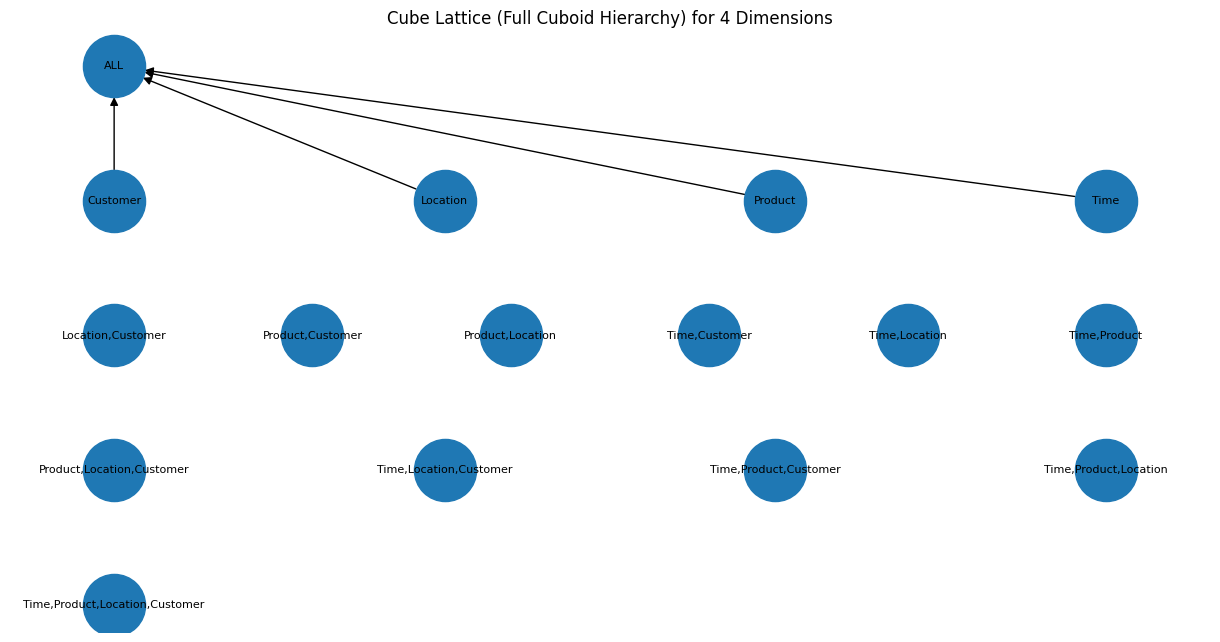


E1: Cuboids and Cube Lattice

Number of dimensions (n) = 2000
Number of cuboids (T) = 2^n = 2^2000 = 144

Cuboids:
- A cuboid is one aggregated “view” of the data cube at a chosen set of dimensions.
- Example cuboids: (Time, Product, Location, Customer) = base cuboid (most detailed),
  (Time, Product) = aggregated over Location and Customer,
  (Product) = aggregated over Time, Location, Customer,
  (ALL) = apex cuboid (fully aggregated).

Cube lattice:
- The cube lattice is the structure that lists all possible cuboids and organizes them by level of aggregation.
- Bottom of the lattice: base cuboid (n-D) contains the most detailed data.
- Top of the lattice: apex cuboid (0-D, ALL) contains the most summarized data.
- Moving upward in the lattice corresponds to roll-up (more aggregation / fewer



In [33]:
from itertools import combinations

dims = ["Time", "Product", "Location", "Customer"]

# Build lattice nodes: all subsets of dims
nodes = []
for k in range(len(dims)+1):
    for subset in combinations(dims, k):
        label = "ALL" if len(subset)==0 else ",".join(subset)
        nodes.append((subset, label))

# Graph where edges connect subsets that differ by one added dimension
L = nx.DiGraph()
for subset, label in nodes:
    L.add_node(label, level=len(subset))

for subset, label in nodes:
    for d in dims:
        if d not in subset:
            sup = tuple(sorted(subset + (d,)))
            sup_label = "ALL" if len(sup)==0 else ",".join(sup)
            if sup_label in L.nodes:
                # Edge from more detailed (superset) to more aggregated (subset) OR vice versa.
                # We'll draw arrows upward (drill-up) from detailed -> aggregated.
                L.add_edge(",".join(sup) if len(sup)>0 else "ALL", label)

# Position nodes by level (dimensionality)
levels = {k: [] for k in range(len(dims)+1)}
for node, data in L.nodes(data=True):
    levels[data["level"]].append(node)

pos = {}
for lvl, lvl_nodes in levels.items():
    # Top level (0 dims) at y=4, bottom level (4 dims) at y=0
    y = len(dims) - lvl
    xs = np.linspace(-2.5, 2.5, num=max(1, len(lvl_nodes)))
    for x, node in zip(xs, sorted(lvl_nodes)):
        pos[node] = (x, y)

plt.figure(figsize=(12,6))
nx.draw(L, pos, with_labels=True, node_size=2000, font_size=8, arrows=True, arrowstyle="-|>", arrowsize=12)
plt.title("Cube Lattice (Full Cuboid Hierarchy) for 4 Dimensions")
plt.axis("off")
plt.show()

n = 4
T = 2**n

Answer = f"""
E1: Cuboids and Cube Lattice

Number of dimensions (n) = {n}
Number of cuboids (T) = 2^n = 2^{n} = {T}

Cuboids:
- A cuboid is one aggregated “view” of the data cube at a chosen set of dimensions.
- Example cuboids: (Time, Product, Location, Customer) = base cuboid (most detailed),
  (Time, Product) = aggregated over Location and Customer,
  (Product) = aggregated over Time, Location, Customer,
  (ALL) = apex cuboid (fully aggregated).

Cube lattice:
- The cube lattice is the structure that lists all possible cuboids and organizes them by level of aggregation.
- Bottom of the lattice: base cuboid (n-D) contains the most detailed data.
- Top of the lattice: apex cuboid (0-D, ALL) contains the most summarized data.
- Moving upward in the lattice corresponds to roll-up (more aggregation / fewer
"""
print(Answer)

## E2) Number of cuboids (with hierarchy levels)

A common formula for the number of cuboids when each dimension i has Lᵢ hierarchy levels is:

**T = Π (Lᵢ + 1)**

This counts the possible choices of aggregation level per dimension (including the ALL level). In real systems, not all cuboids are materialized due to storage/maintenance cost; instead, a carefully chosen subset is stored.

**Source code explanation:** The next cell is an answer cell where you compute T for the provided numbers. You can either compute it manually or write Python code to compute it.

In [34]:
# ✅ Exercise E2 (Answer Cell) — with hierarchy levels

Li_time = 3
Li_product = 2
Li_location = 3
Li_customer = 2

T = (Li_time + 1) * (Li_product + 1) * (Li_location + 1) * (Li_customer + 1)

explain_E2 = f"""
E2: Number of cuboids (with hierarchy levels)
Formula: T = Π (Li + 1)

Time Li = {Li_time}
Product Li = {Li_product}
Location Li = {Li_location}
Customer Li = {Li_customer}

T = ({Li_time}+1)({Li_product}+1)({Li_location}+1)({Li_customer}+1) = {T}
"""

print("T =", T)
print(explain_E2)

T = 144

E2: Number of cuboids (with hierarchy levels)
Formula: T = Π (Li + 1)

Time Li = 3
Product Li = 2
Location Li = 3
Customer Li = 2

T = (3+1)(2+1)(3+1)(2+1) = 144



## E3) Indexing ideas (bitmap + join index)

Bitmap indexes accelerate filtering on low-cardinality attributes by representing membership with bit vectors. Join indexes accelerate star-join patterns by precomputing mappings between dimension values and fact rows. Both approaches reduce expensive scans and joins—critical in large warehouses where fact tables may contain billions of rows.

**Theoretical depth:** Index choice depends on cardinality, workload, and storage. Bitmap indexes shine for attributes like gender/segment/state (few values) and support fast bitwise AND/OR composition for multi-filter queries. Join indexes are especially relevant to star schemas: they act like precomputed join paths, reducing join cost. Modern engines may implement these concepts differently (e.g., compressed bitmaps, zone maps, bloom filters), but the principle is the same: push down filters and minimize I/O.

**Source code explanation:** The next cell is an answer placeholder. You will write the conceptual reason bitmap indexing fails for high-cardinality attributes (bitmaps become huge and less selective, increasing memory/storage and compute cost).

In [35]:
# ✅ Exercise E3 (Answer Cell)
answer_E3 =
"""
Bitmap indexing becomes inefficient for high-cardinality attributes because:

1) Too many distinct values → too many bitmaps
   - A bitmap index typically stores one bitmap per distinct value.
   - High-cardinality (e.g., CustomerID) can create millions of bitmaps.

2) Storage/memory blow-up
   - Each bitmap is as long as the number of fact rows.
   - Even if sparse/compressed, managing a huge number of bitmaps increases overhead.

3) Poor selectivity benefit vs cost
   - Queries may still need to touch many bitmaps, and bitwise operations become heavy.
   - Compression is less effective when values are highly unique/random.

4) Expensive maintenance for updates
   - Inserts/updates require modifying bitmaps, which is costly at scale.

Therefore, bitmap indexes are best for low-cardinality columns (e.g., gender, status, segment),
but not for high-cardinality attributes (e.g., transaction_id, customer_id).
"""
print(answer_E3)


Bitmap indexing becomes inefficient for high-cardinality attributes because:

1) Too many distinct values → too many bitmaps
   - A bitmap index typically stores one bitmap per distinct value.
   - High-cardinality (e.g., CustomerID) can create millions of bitmaps.

2) Storage/memory blow-up
   - Each bitmap is as long as the number of fact rows.
   - Even if sparse/compressed, managing a huge number of bitmaps increases overhead.

3) Poor selectivity benefit vs cost
   - Queries may still need to touch many bitmaps, and bitwise operations become heavy.
   - Compression is less effective when values are highly unique/random.

4) Expensive maintenance for updates
   - Inserts/updates require modifying bitmaps, which is costly at scale.

Therefore, bitmap indexes are best for low-cardinality columns (e.g., gender, status, segment),
but not for high-cardinality attributes (e.g., transaction_id, customer_id).



---

# PART F — Attribute-Oriented Induction (AOI) vs OLAP (Deeper Theory)

AOI is a concept generalization technique used in knowledge discovery. It starts from task-relevant tuples (selected by a query), then performs **attribute removal** (drop attributes with too many distinct values and no useful generalization) and **attribute generalization** (map values to higher-level concepts), and finally **aggregation** (merge identical generalized tuples and count them). AOI can produce descriptive rules like “Most graduate students are from Malaysia and have GPA between 3.0–4.0”.

**Theoretical depth:** OLAP and AOI both summarize data across multiple abstraction levels, but they differ in emphasis. OLAP is cube-centric: systematic, often query-independent preprocessing, with explicit hierarchies and the ability to drill down to detailed levels. AOI is more automation-oriented: it can decide suitable generalization levels (threshold controls) and can be applied even when data is not perfectly modeled as a cube. Conceptually, AOI is closer to “summarize this class” tasks and can integrate relevance analysis when there are many attributes.

**Source code explanation:** The next cell is an answer placeholder. You will propose which attributes to remove/generalize and what the summarized output might look like.

In [39]:
# ✅ Exercise F1 (Answer Cell)
answer_F1 = f"""
F1) AOI proposal

Assume a typical “Student” dataset with attributes like:
(StudentID, Name, Age, GPA, Major, ProgramLevel, City, State, Country, EnrollmentYear)

1) Attribute Removal (too specific / high-cardinality / no useful hierarchy)
- Remove StudentID, Name: unique identifiers (very high cardinality), do not help summarization.
- Remove exact City if it causes too many distinct values (keep higher level like State/Country instead).

2) Attribute Generalization
- Age → AgeGroup (e.g., 17–19, 20–22, 23–25, >25)
- GPA → GPA_Range (e.g., 0–2.0, 2.0–3.0, 3.0–3.5, 3.5–4.0)
- Major → Faculty/School group (e.g., “Computer Eng” → “Engineering”)
- Location → City → State → Country (choose a level that keeps the result compact)
- EnrollmentYear → EnrollmentPeriod (e.g., 2022–2023, 2024–2025) or just Year

3) Aggregation
Example generalized output:
(AgeGroup, GPA_Range, Faculty, Country, Count)
- (20–22, 3.5–4.0, Engineering, Malaysia, 120)
- (20–22, 3.0–3.5, Engineering, Malaysia, 95)
- (17–19, 3.0–3.5, Science, Malaysia, 60)
- (23–25, 2.0–3.0, Business, International, 30)

4) Example descriptive rule produced by AOI
“Most students in Engineering from Malaysia have GPA between 3.0–4.0, with the largest group in age 20–22.”

Key idea: AOI automatically chooses/removes overly detailed attributes and generalizes others into concept hierarchies,
then counts occurrences to produce compact summaries/rules.
"""

print(answer_F1)


F1) AOI proposal

Assume a typical “Student” dataset with attributes like:
(StudentID, Name, Age, GPA, Major, ProgramLevel, City, State, Country, EnrollmentYear)

1) Attribute Removal (too specific / high-cardinality / no useful hierarchy)
- Remove StudentID, Name: unique identifiers (very high cardinality), do not help summarization.
- Remove exact City if it causes too many distinct values (keep higher level like State/Country instead).

2) Attribute Generalization
- Age → AgeGroup (e.g., 17–19, 20–22, 23–25, >25)
- GPA → GPA_Range (e.g., 0–2.0, 2.0–3.0, 3.0–3.5, 3.5–4.0)
- Major → Faculty/School group (e.g., “Computer Eng” → “Engineering”)
- Location → City → State → Country (choose a level that keeps the result compact)
- EnrollmentYear → EnrollmentPeriod (e.g., 2022–2023, 2024–2025) or just Year

3) Aggregation
Example generalized output:
(AgeGroup, GPA_Range, Faculty, Country, Count)
- (20–22, 3.5–4.0, Engineering, Malaysia, 120)
- (20–22, 3.0–3.5, Engineering, Malaysia, 95)
- (

---

# ✅ Lab Submission Checklist

1. Answers: **A1, A2, B1, C1, D1, E1/E2/E3, F1**
2. Make sure the Screenshots/outputs below is shown in the PDF submission file:
   - Star schema diagram
   - Snowflake schema diagram
   - Cube lattice diagram
3. Reflection (~200 words): **Differences between OLAP and AOI**